In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import simplex_projection
from core_ntsa.generators import simulate_rossler, simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise

In [13]:
trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
x_signal = trajectories[0, :3000]
x_noise = add_white_noise(x_signal, snr_db=20.0)

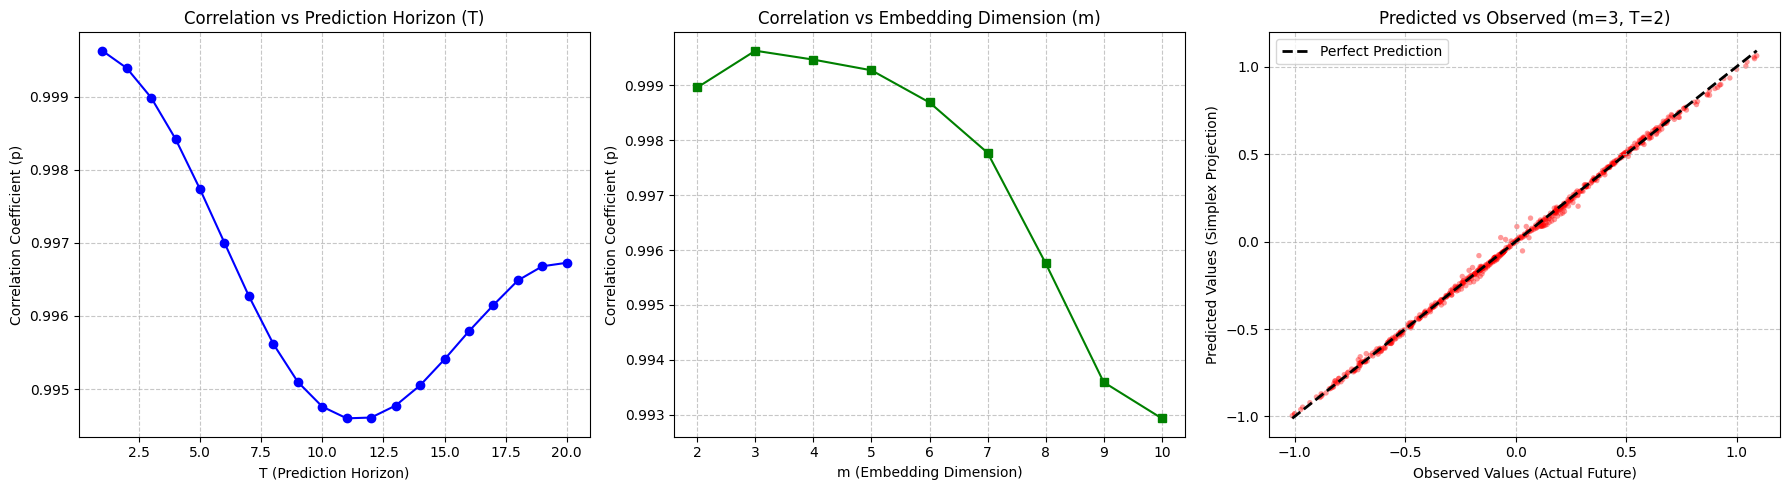

In [2]:
def run_lorenz_simplex_experiments():
    """
    Thực thi kiểm chứng thuật toán Simplex Projection trên hệ Lorenz
    và vẽ 3 đồ thị phân tích: p(T), p(m), và scatter ypred vs yobsever.
    """
    # 1. Khởi tạo và trích xuất dữ liệu
    # Hệ Lorenz mặc định dt=0.01. Chọn t_span=50.0 để có 5000 điểm.
    # Hàm simulate_lorenz mặc định đã cắt 1000 điểm transient.
    trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
    x_signal = trajectories[0, :3000]
    
    # Đặt độ trễ tau = 10 (tương ứng 0.1 giây hệ thống, phù hợp với Lorenz)
    tau = 10
    
    # 2. Thực nghiệm 1: Tính p(T) - Suy giảm tương quan theo tầm nhìn dự báo
    m_fixed = 3
    t_max = 20
    t_range = np.arange(1, t_max + 1)
    p_t_list = []
    
    for t_horizon in t_range:
        p, _, _ = simplex_projection(x_signal, tau=tau, m=m_fixed, T=t_horizon)
        p_t_list.append(p)
        
    # 3. Thực nghiệm 2: Tính p(m) - Đánh giá chiều nhúng tối ưu
    t_fixed = 1
    m_max = 10
    m_range = np.arange(2, m_max + 1)
    p_m_list = []
    
    for m_dim in m_range:
        p, _, _ = simplex_projection(x_signal, tau=tau, m=m_dim, T=t_fixed)
        p_m_list.append(p)
        
    # 4. Thực nghiệm 3: Trích xuất ypred và yobsever tại cấu hình cụ thể
    m_scatter = 3
    t_scatter = 2
    _, ypred, yobs = simplex_projection(x_signal, tau=tau, m=m_scatter, T=t_scatter)
    
    # 5. Khởi tạo figure và vẽ đồ thị
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị 1: p(T)
    axes[0].plot(t_range, p_t_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Correlation vs Prediction Horizon (T)')
    axes[0].set_xlabel('T (Prediction Horizon)')
    axes[0].set_ylabel('Correlation Coefficient (p)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 2: p(m)
    axes[1].plot(m_range, p_m_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Correlation vs Embedding Dimension (m)')
    axes[1].set_xlabel('m (Embedding Dimension)')
    axes[1].set_ylabel('Correlation Coefficient (p)')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 3: ypred vs yobsever
    axes[2].scatter(yobs, ypred, alpha=0.4, color='red', s=15, edgecolors='none')
    
    # Vẽ đường chéo tham chiếu y = x (Dự báo hoàn hảo)
    min_val = min(np.min(yobs), np.min(ypred))
    max_val = max(np.max(yobs), np.max(ypred))
    axes[2].plot([min_val, max_val], [min_val, max_val], color='black', 
                 linestyle='--', linewidth=2, label='Perfect Prediction')
    
    axes[2].set_title(f'Predicted vs Observed (m={m_scatter}, T={t_scatter})')
    axes[2].set_xlabel('Observed Values (Actual Future)')
    axes[2].set_ylabel('Predicted Values (Simplex Projection)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lorenz_simplex_experiments()

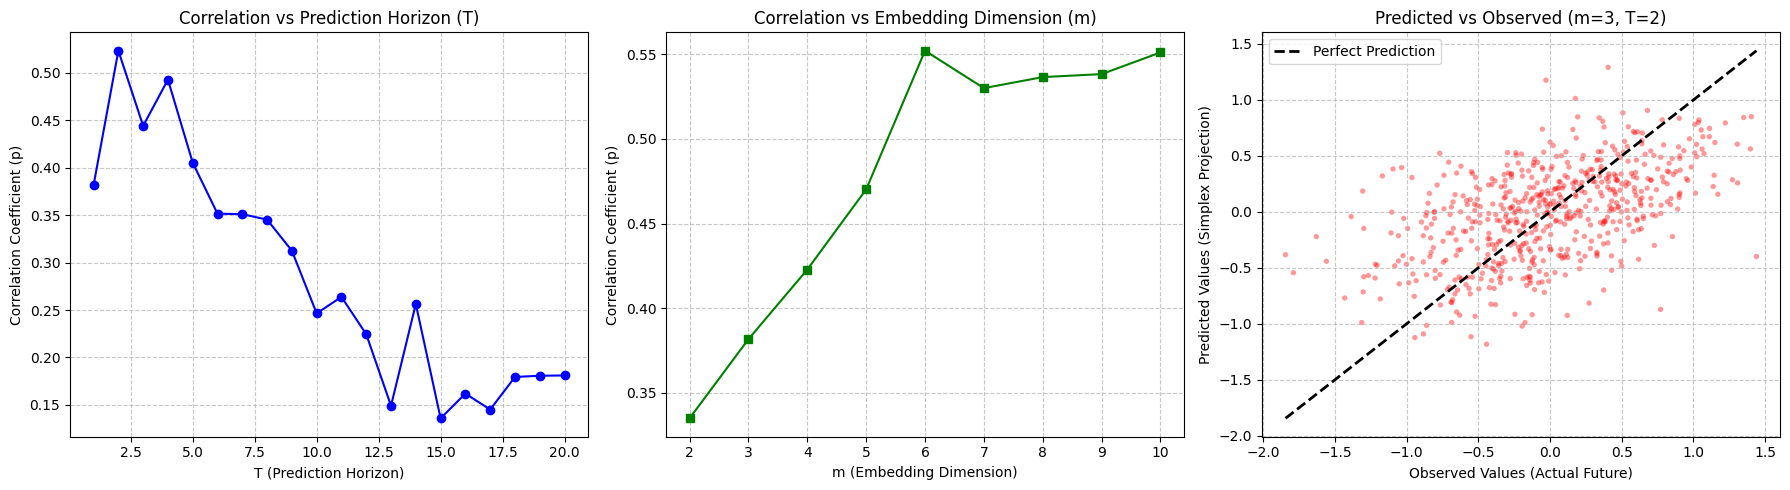

In [11]:
def run_lorenz_simplex_experiments_add_noise():
    """
    Thực thi kiểm chứng thuật toán Simplex Projection trên hệ Lorenz
    và vẽ 3 đồ thị phân tích: p(T), p(m), và scatter ypred vs yobsever.
    """
    # 1. Khởi tạo và trích xuất dữ liệu
    # Hệ Lorenz mặc định dt=0.01. Chọn t_span=50.0 để có 5000 điểm.
    # Hàm simulate_lorenz mặc định đã cắt 1000 điểm transient.
    trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
    x_signal = trajectories[0, :3000]
    x_noise = add_white_noise(x_signal, snr_db=30.0)
    # Đặt độ trễ tau = 10 (tương ứng 0.1 giây hệ thống, phù hợp với Lorenz)
    tau = 10
    
    # 2. Thực nghiệm 1: Tính p(T) - Suy giảm tương quan theo tầm nhìn dự báo
    m_fixed = 3
    t_max = 20
    t_range = np.arange(1, t_max + 1)
    p_t_list = []
    
    for t_horizon in t_range:
        p, _, _ = simplex_projection(x_noise, tau=tau, m=m_fixed, T=t_horizon)
        p_t_list.append(p)
        
    # 3. Thực nghiệm 2: Tính p(m) - Đánh giá chiều nhúng tối ưu
    t_fixed = 1
    m_max = 10
    m_range = np.arange(2, m_max + 1)
    p_m_list = []
    
    for m_dim in m_range:
        p, _, _ = simplex_projection(x_noise, tau=tau, m=m_dim, T=t_fixed)
        p_m_list.append(p)
        
    # 4. Thực nghiệm 3: Trích xuất ypred và yobsever tại cấu hình cụ thể
    m_scatter = 3
    t_scatter = 2
    _, ypred, yobs = simplex_projection(x_noise, tau=tau, m=m_scatter, T=t_scatter)
    
    # 5. Khởi tạo figure và vẽ đồ thị
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị 1: p(T)
    axes[0].plot(t_range, p_t_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Correlation vs Prediction Horizon (T)')
    axes[0].set_xlabel('T (Prediction Horizon)')
    axes[0].set_ylabel('Correlation Coefficient (p)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 2: p(m)
    axes[1].plot(m_range, p_m_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Correlation vs Embedding Dimension (m)')
    axes[1].set_xlabel('m (Embedding Dimension)')
    axes[1].set_ylabel('Correlation Coefficient (p)')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 3: ypred vs yobsever
    axes[2].scatter(yobs, ypred, alpha=0.4, color='red', s=15, edgecolors='none')
    
    # Vẽ đường chéo tham chiếu y = x (Dự báo hoàn hảo)
    min_val = min(np.min(yobs), np.min(ypred))
    max_val = max(np.max(yobs), np.max(ypred))
    axes[2].plot([min_val, max_val], [min_val, max_val], color='black', 
                 linestyle='--', linewidth=2, label='Perfect Prediction')
    
    axes[2].set_title(f'Predicted vs Observed (m={m_scatter}, T={t_scatter})')
    axes[2].set_xlabel('Observed Values (Actual Future)')
    axes[2].set_ylabel('Predicted Values (Simplex Projection)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lorenz_simplex_experiments_add_noise()

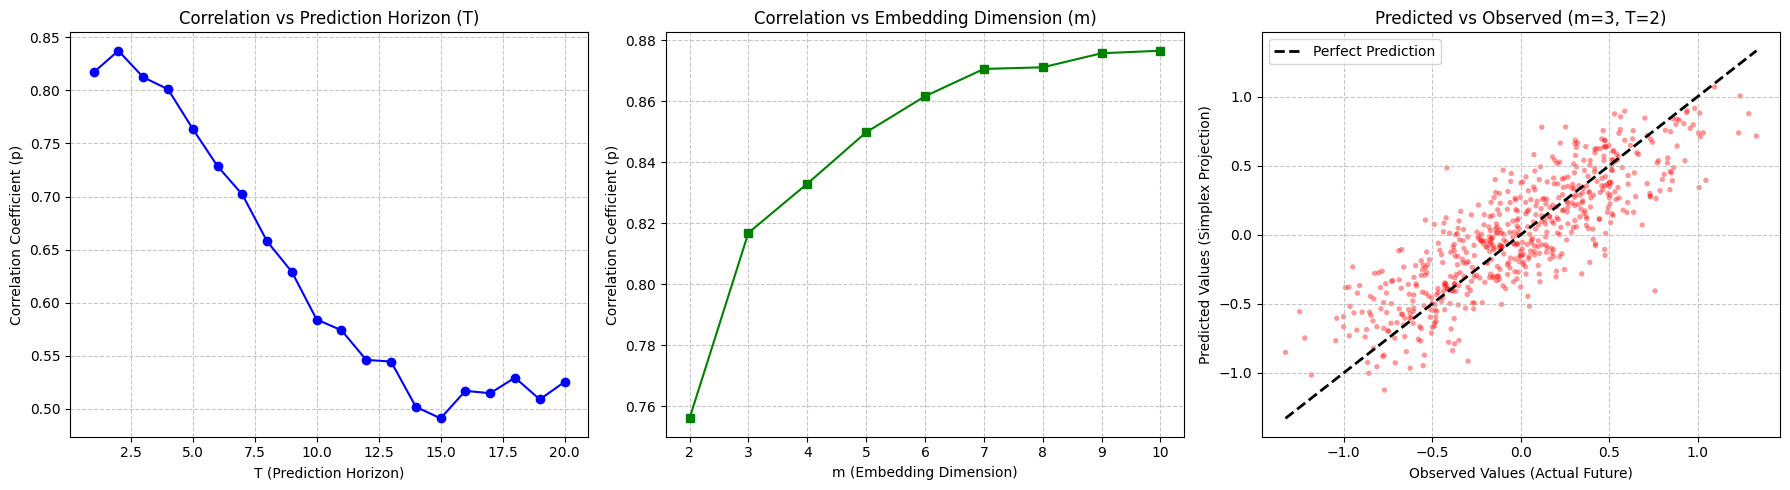

In [12]:
def run_lorenz_simplex_experiments_add_noise_colored():
    """
    Thực thi kiểm chứng thuật toán Simplex Projection trên hệ Lorenz
    và vẽ 3 đồ thị phân tích: p(T), p(m), và scatter ypred vs yobsever.
    """
    # 1. Khởi tạo và trích xuất dữ liệu
    # Hệ Lorenz mặc định dt=0.01. Chọn t_span=50.0 để có 5000 điểm.
    # Hàm simulate_lorenz mặc định đã cắt 1000 điểm transient.
    trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
    x_signal = trajectories[0, :3000]
    x_noise = add_colored_noise(x_signal,color='pink', snr_db=30.0)
    # Đặt độ trễ tau = 10 (tương ứng 0.1 giây hệ thống, phù hợp với Lorenz)
    tau = 10
    
    # 2. Thực nghiệm 1: Tính p(T) - Suy giảm tương quan theo tầm nhìn dự báo
    m_fixed = 3
    t_max = 20
    t_range = np.arange(1, t_max + 1)
    p_t_list = []
    
    for t_horizon in t_range:
        p, _, _ = simplex_projection(x_noise, tau=tau, m=m_fixed, T=t_horizon)
        p_t_list.append(p)
        
    # 3. Thực nghiệm 2: Tính p(m) - Đánh giá chiều nhúng tối ưu
    t_fixed = 1
    m_max = 10
    m_range = np.arange(2, m_max + 1)
    p_m_list = []
    
    for m_dim in m_range:
        p, _, _ = simplex_projection(x_noise, tau=tau, m=m_dim, T=t_fixed)
        p_m_list.append(p)
        
    # 4. Thực nghiệm 3: Trích xuất ypred và yobsever tại cấu hình cụ thể
    m_scatter = 3
    t_scatter = 2
    _, ypred, yobs = simplex_projection(x_noise, tau=tau, m=m_scatter, T=t_scatter)
    
    # 5. Khởi tạo figure và vẽ đồ thị
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị 1: p(T)
    axes[0].plot(t_range, p_t_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Correlation vs Prediction Horizon (T)')
    axes[0].set_xlabel('T (Prediction Horizon)')
    axes[0].set_ylabel('Correlation Coefficient (p)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 2: p(m)
    axes[1].plot(m_range, p_m_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Correlation vs Embedding Dimension (m)')
    axes[1].set_xlabel('m (Embedding Dimension)')
    axes[1].set_ylabel('Correlation Coefficient (p)')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 3: ypred vs yobsever
    axes[2].scatter(yobs, ypred, alpha=0.4, color='red', s=15, edgecolors='none')
    
    # Vẽ đường chéo tham chiếu y = x (Dự báo hoàn hảo)
    min_val = min(np.min(yobs), np.min(ypred))
    max_val = max(np.max(yobs), np.max(ypred))
    axes[2].plot([min_val, max_val], [min_val, max_val], color='black', 
                 linestyle='--', linewidth=2, label='Perfect Prediction')
    
    axes[2].set_title(f'Predicted vs Observed (m={m_scatter}, T={t_scatter})')
    axes[2].set_xlabel('Observed Values (Actual Future)')
    axes[2].set_ylabel('Predicted Values (Simplex Projection)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lorenz_simplex_experiments_add_noise_colored()

### TÓM TẮT ĐÁNH GIÁ: HIỆU NĂNG SIMPLEX PROJECTION TRÊN HỆ LORENZ

**1. Hệ Lorenz Lý tưởng (Deterministic Chaos)**
* **$p(T)$ (Chữ ký hỗn loạn):** Bắt đầu tiệm cận $1.0$ và suy giảm mượt mà khi $T$ tăng. Thể hiện tính tất định nhưng nhạy cảm với điều kiện ban đầu (khả năng dự báo ngắn hạn tốt, phân kỳ trong dài hạn).
* **$p(m)$ (Tối ưu hóa không gian):** Đạt đỉnh sắc nét tại $m=3$. Phản ánh chính xác việc hệ thống bị giới hạn trong một bộ hút có số chiều fractal thấp ($D \approx 2.06$).

**2. Tác động của Nhiễu Trắng (White Noise)**
* **$p(T)$:** Sụp đổ tức thì ngay từ bước dự báo đầu tiên ($T=1$). Cấu trúc quỹ đạo bị vỡ vụn, mất hoàn toàn năng lực nội suy.
* **$p(m)$:** Đồ thị tăng liên tục và không tạo đỉnh. Thể hiện hiện tượng *Overfitting*, thuật toán cố gắng khai thác các chiều không gian dư thừa để khớp với bản chất vô hạn chiều của nhiễu ngẫu nhiên.

**3. Tác động của Nhiễu Màu (Colored Noise)**
* **$p(T)$:** Khởi đầu ở mức cao và suy giảm mượt mà. Đặc tính tự tương quan thời gian (quán tính) tạo ra ảo giác đánh lừa, khiến đồ thị trông giống hệt một hệ hỗn loạn tất định.
* **$p(m)$:** Tăng liên tục, không có đỉnh rõ rệt ở các chiều thấp. Đây là đặc trưng "chiếu yêu" quyết định để bóc trần hệ thống không sở hữu bộ hút tất định nào, tách bạch hoàn toàn nhiễu màu khỏi cấu trúc Chaos thực sự.

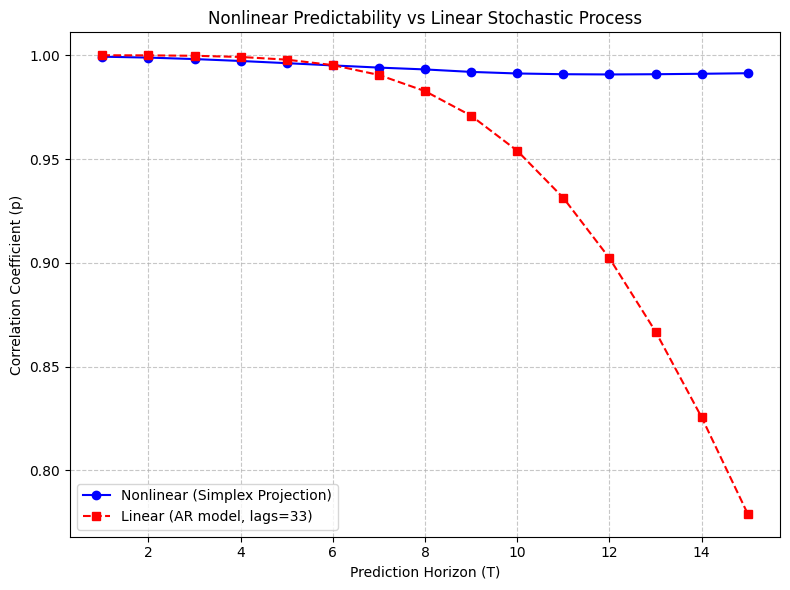

Mean Correlation p(T) - Simplex: 0.9940
Mean Correlation p(T) - AR: 0.9463
Wilcoxon Test P-value (Simplex > AR): 1.28e-02
Kết luận: Hệ thống chứa động lực học phi tuyến có ý nghĩa thống kê.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, wilcoxon
import sys
import os

sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import simplex_projection

def ar_prediction(signal, lags, T, train_ratio=0.8):
    """
    Dự báo tuyến tính toàn cục (AR).
    Căn chỉnh mốc thời gian lịch sử chuẩn xác với khối Simplex.
    """
    y = np.diff(signal)
    n_points = len(y)
    
    min_t = lags - 1
    max_t = n_points - T
    
    if min_t >= max_t:
        raise ValueError("Độ dài tín hiệu không đủ cho cấu hình AR hiện tại.")
        
    valid_t = np.arange(min_t, max_t)
    num_vecs = len(valid_t)
    
    X = np.zeros((num_vecs, lags))
    Y_target = np.zeros(num_vecs)
    
    for i, t in enumerate(valid_t):
        X[i, :] = y[t - lags + 1 : t + 1]
        Y_target[i] = y[t + T]
        
    split_idx = int(num_vecs * train_ratio)
    
    X_train = X[:split_idx]
    Y_train = Y_target[:split_idx]
    X_test = X[split_idx:]
    Y_test = Y_target[split_idx:]
    
    # Thêm cột bias cho mô hình hồi quy
    X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
    X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]
    
    theta, _, _, _ = np.linalg.lstsq(X_train_b, Y_train, rcond=None)
    ypred_ar = X_test_b @ theta
    
    if np.std(ypred_ar) == 0 or np.std(Y_test) == 0:
        p_ar = 0.0
    else:
        p_ar, _ = pearsonr(ypred_ar, Y_test)
        
    return p_ar, ypred_ar, Y_test

def evaluate_chaos_significance(data, tau, m, max_T=15, train_ratio=0.8):
    """
    So sánh đường cong correlation p(T) giữa Simplex và AR.
    Sử dụng Wilcoxon để kiểm định ý nghĩa thống kê của sự vượt trội.
    """
    t_range = np.arange(1, max_T + 1)
    p_simplex_list = []
    p_ar_list = []
    
    # Cân bằng lượng thông tin lịch sử đầu vào cho mô hình AR
    ar_lags = (m - 1) * tau + 1
    
    for T in t_range:
        p_simp, _, _ = simplex_projection(
            data, tau=tau, m=m, T=T, train_ratio=train_ratio
        )
        p_ar, _, _ = ar_prediction(
            data, lags=ar_lags, T=T, train_ratio=train_ratio
        )
        
        p_simplex_list.append(p_simp)
        p_ar_list.append(p_ar)
            
    # Kiểm định giả thuyết: Đường cong correlation của Simplex LỚN HƠN có ý nghĩa so với AR
    stat, p_value = wilcoxon(p_simplex_list, p_ar_list, alternative='greater')
    
    plt.figure(figsize=(8, 6))
    plt.plot(t_range, p_simplex_list, marker='o', color='blue', 
             label='Nonlinear (Simplex Projection)')
    plt.plot(t_range, p_ar_list, marker='s', color='red', linestyle='--', 
             label=f'Linear (AR model, lags={ar_lags})')
    
    plt.title('Nonlinear Predictability vs Linear Stochastic Process')
    plt.xlabel('Prediction Horizon (T)')
    plt.ylabel('Correlation Coefficient (p)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"Mean Correlation p(T) - Simplex: {np.mean(p_simplex_list):.4f}")
    print(f"Mean Correlation p(T) - AR: {np.mean(p_ar_list):.4f}")
    print(f"Wilcoxon Test P-value (Simplex > AR): {p_value:.2e}")
    
    if p_value < 0.05:
        print("Kết luận: Hệ thống chứa động lực học phi tuyến có ý nghĩa thống kê.")
    else:
        print("Kết luận: Không vượt qua được bài kiểm tra nhiễu tuyến tính tương quan.")
        
    return p_value, p_simplex_list, p_ar_list

p_val, p_simp, p_ar = evaluate_chaos_significance(x_signal, tau=16, m=3, max_T=15)

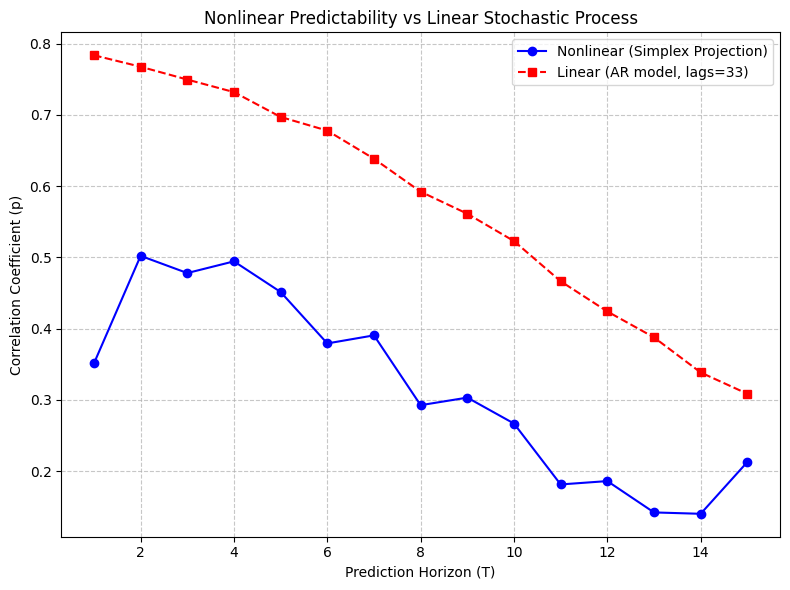

Mean Correlation p(T) - Simplex: 0.3181
Mean Correlation p(T) - AR: 0.5766
Wilcoxon Test P-value (Simplex > AR): 1.00e+00
Kết luận: Không vượt qua được bài kiểm tra nhiễu tuyến tính tương quan.


In [6]:
p_val, p_simp, p_ar = evaluate_chaos_significance(x_noise, tau=16, m=3, max_T=15)

### GIẢI PHẪU TOÁN HỌC: SỰ SỤP ĐỔ CỦA SIMPLEX TRƯỚC AR KHI CÓ NHIỄU

**1. Hệ Lorenz Lý tưởng (Simplex > AR | P-value < 0.05)**
* **Simplex ($\rho = 0.9940$):** Nội suy hình học cục bộ xuất sắc. Thuật toán bắt trọn cấu trúc phi tuyến phức tạp (độ cong đa tạp) của hình cánh bướm Lorenz.
* **AR ($\rho = 0.9463$):** Chỉ khai thác được quán tính tuyến tính ngắn hạn ($T=1$) theo xấp xỉ tuyến tính (chuỗi Taylor), không học được cấu trúc hình học vĩ mô.

**2. Hệ Lorenz + Nhiễu Trắng (AR > Simplex | P-value = 1.0)**
* **Simplex Sụp đổ thảm khốc ($\rho = 0.3181$):** Gót chân Achilles của phương pháp cục bộ (Local). Nhiễu trắng làm nhòe bộ hút (Attractor Broadening), sinh ra các **láng giềng giả (false neighbors)**. Simplex lấy trung bình động lực của các điểm giả này khiến dự báo sai lệch hoàn toàn.
* **AR Trụ vững tương đối ($\rho = 0.5766$):** Sức mạnh của hồi quy toàn cục (Global OLS). Thuật toán giải bài toán tối ưu trên toàn tập dữ liệu, đóng vai trò như bộ lọc thông thấp san phẳng nhiễu ngẫu nhiên (zero-mean), bảo toàn được xu hướng quán tính gốc của hệ thống.

---
**🎯 Kết luận cốt lõi:**
Sự sụp đổ bất đối xứng này chứng minh: Thuật toán phi tuyến (Simplex) sắc bén với cấu trúc cong nhưng **mỏng manh** trước nhiễu cục bộ; mô hình tuyến tính (AR) mù lòa trước hình học phi tuyến nhưng **lì lợm** trước nhiễu trắng nhờ bộ lọc trung bình toàn cục.

# SIMPLEX PROJECTION NOT DIFFERENCE


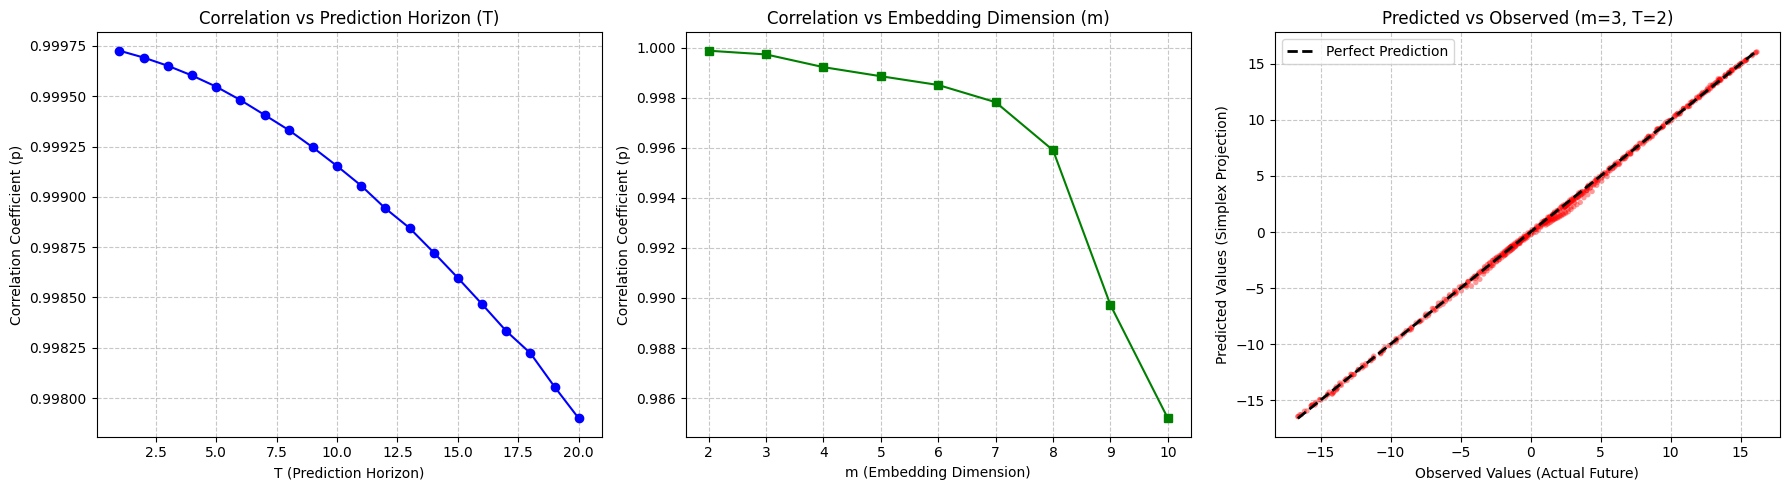

In [11]:
from core_ntsa.predicting import simplex_projection_not_dif
def run_lorenz_simplex_experiments():
    """
    Thực thi kiểm chứng thuật toán Simplex Projection trên hệ Lorenz
    và vẽ 3 đồ thị phân tích: p(T), p(m), và scatter ypred vs yobsever.
    """
    # 1. Khởi tạo và trích xuất dữ liệu
    # Hệ Lorenz mặc định dt=0.01. Chọn t_span=50.0 để có 5000 điểm.
    # Hàm simulate_lorenz mặc định đã cắt 1000 điểm transient.
    trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
    x_signal = trajectories[0, :3000]
    
    # Đặt độ trễ tau = 10 (tương ứng 0.1 giây hệ thống, phù hợp với Lorenz)
    tau = 16
    
    # 2. Thực nghiệm 1: Tính p(T) - Suy giảm tương quan theo tầm nhìn dự báo
    m_fixed = 3
    t_max = 20
    t_range = np.arange(1, t_max + 1)
    p_t_list = []
    
    for t_horizon in t_range:
        p, _, _ = simplex_projection_not_dif(x_signal, tau=tau, m=m_fixed, T=t_horizon)
        p_t_list.append(p)
        
    # 3. Thực nghiệm 2: Tính p(m) - Đánh giá chiều nhúng tối ưu
    t_fixed = 1
    m_max = 10
    m_range = np.arange(2, m_max + 1)
    p_m_list = []
    
    for m_dim in m_range:
        p, _, _ = simplex_projection_not_dif(x_signal, tau=tau, m=m_dim, T=t_fixed)
        p_m_list.append(p)
        
    # 4. Thực nghiệm 3: Trích xuất ypred và yobsever tại cấu hình cụ thể
    m_scatter = 3
    t_scatter = 2
    _, ypred, yobs = simplex_projection_not_dif(x_signal, tau=tau, m=m_scatter, T=t_scatter)
    
    # 5. Khởi tạo figure và vẽ đồ thị
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị 1: p(T)
    axes[0].plot(t_range, p_t_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Correlation vs Prediction Horizon (T)')
    axes[0].set_xlabel('T (Prediction Horizon)')
    axes[0].set_ylabel('Correlation Coefficient (p)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 2: p(m)
    axes[1].plot(m_range, p_m_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Correlation vs Embedding Dimension (m)')
    axes[1].set_xlabel('m (Embedding Dimension)')
    axes[1].set_ylabel('Correlation Coefficient (p)')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 3: ypred vs yobsever
    axes[2].scatter(yobs, ypred, alpha=0.4, color='red', s=15, edgecolors='none')
    
    # Vẽ đường chéo tham chiếu y = x (Dự báo hoàn hảo)
    min_val = min(np.min(yobs), np.min(ypred))
    max_val = max(np.max(yobs), np.max(ypred))
    axes[2].plot([min_val, max_val], [min_val, max_val], color='black', 
                 linestyle='--', linewidth=2, label='Perfect Prediction')
    
    axes[2].set_title(f'Predicted vs Observed (m={m_scatter}, T={t_scatter})')
    axes[2].set_xlabel('Observed Values (Actual Future)')
    axes[2].set_ylabel('Predicted Values (Simplex Projection)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lorenz_simplex_experiments()

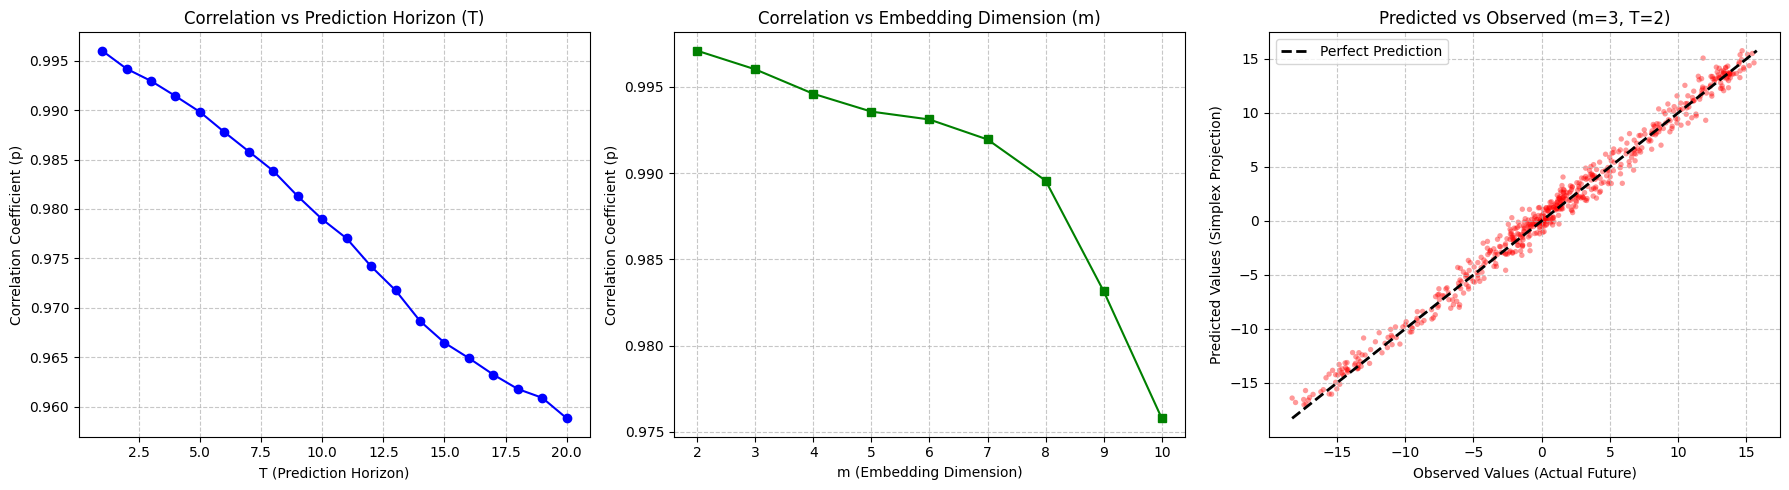

In [15]:
def run_lorenz_simplex_experiments_add_noise_colored():
    """
    Thực thi kiểm chứng thuật toán Simplex Projection trên hệ Lorenz
    và vẽ 3 đồ thị phân tích: p(T), p(m), và scatter ypred vs yobsever.
    """
    # 1. Khởi tạo và trích xuất dữ liệu
    # Hệ Lorenz mặc định dt=0.01. Chọn t_span=50.0 để có 5000 điểm.
    # Hàm simulate_lorenz mặc định đã cắt 1000 điểm transient.
    trajectories = simulate_lorenz(t_span=50.0, dt=0.01)
    
    # Lấy đúng 3000 điểm của tọa độ x làm chuỗi tín hiệu 1D
    x_signal = trajectories[0, :3000]
    x_noise = add_colored_noise(x_signal,color='pink', snr_db=20.0)
    # Đặt độ trễ tau = 10 (tương ứng 0.1 giây hệ thống, phù hợp với Lorenz)
    tau = 16
    
    # 2. Thực nghiệm 1: Tính p(T) - Suy giảm tương quan theo tầm nhìn dự báo
    m_fixed = 3
    t_max = 20
    t_range = np.arange(1, t_max + 1)
    p_t_list = []
    
    for t_horizon in t_range:
        p, _, _ = simplex_projection_not_dif(x_noise, tau=tau, m=m_fixed, T=t_horizon)
        p_t_list.append(p)
        
    # 3. Thực nghiệm 2: Tính p(m) - Đánh giá chiều nhúng tối ưu
    t_fixed = 1
    m_max = 10
    m_range = np.arange(2, m_max + 1)
    p_m_list = []
    
    for m_dim in m_range:
        p, _, _ = simplex_projection_not_dif(x_noise, tau=tau, m=m_dim, T=t_fixed)
        p_m_list.append(p)
        
    # 4. Thực nghiệm 3: Trích xuất ypred và yobsever tại cấu hình cụ thể
    m_scatter = 3
    t_scatter = 2
    _, ypred, yobs = simplex_projection_not_dif(x_noise, tau=tau, m=m_scatter, T=t_scatter)
    
    # 5. Khởi tạo figure và vẽ đồ thị
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị 1: p(T)
    axes[0].plot(t_range, p_t_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Correlation vs Prediction Horizon (T)')
    axes[0].set_xlabel('T (Prediction Horizon)')
    axes[0].set_ylabel('Correlation Coefficient (p)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 2: p(m)
    axes[1].plot(m_range, p_m_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Correlation vs Embedding Dimension (m)')
    axes[1].set_xlabel('m (Embedding Dimension)')
    axes[1].set_ylabel('Correlation Coefficient (p)')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Đồ thị 3: ypred vs yobsever
    axes[2].scatter(yobs, ypred, alpha=0.4, color='red', s=15, edgecolors='none')
    
    # Vẽ đường chéo tham chiếu y = x (Dự báo hoàn hảo)
    min_val = min(np.min(yobs), np.min(ypred))
    max_val = max(np.max(yobs), np.max(ypred))
    axes[2].plot([min_val, max_val], [min_val, max_val], color='black', 
                 linestyle='--', linewidth=2, label='Perfect Prediction')
    
    axes[2].set_title(f'Predicted vs Observed (m={m_scatter}, T={t_scatter})')
    axes[2].set_xlabel('Observed Values (Actual Future)')
    axes[2].set_ylabel('Predicted Values (Simplex Projection)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lorenz_simplex_experiments_add_noise_colored()